#IMPORTING IMPORTANT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

#ANALYSING SENTIMENT DATASET(FEAR-GREED DATASET)


In [3]:
#loading datasets
sentiment=pd.read_csv("fear_greed_index.csv")


In [4]:
sentiment.shape


(2644, 4)

#there are 2644 rows and 4 columns in fear_greed_index.csv dataset



In [5]:

sentiment.head()



,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


#Is there any missing values or duplicate row present in sentiment

In [67]:

print(sentiment.isnull().sum())




timestamp         0
value             0
classification    0
date              0
dtype: int64


#there is no null value present in any of the column
#if there would be any null value present we would have seen:
#how many null values are present in each column(feature),
#then will see whether the feature is important or not
#if feature is not important we would drop them
#if feature is important we would fill them 
#if feature is numerical fill it by  mean,median or mode 




In [68]:

sentiment.duplicated().sum()


np.int64(0)

#if any duplicate row is present in the dataset,if present we would drop them
#There is no duplicate rows preseent in the dataset

#ANALYSING THE TRADER DATASET


In [8]:
trades=pd.read_csv("historical_data.csv")
trades.shape

(211224, 16)

#there are 211224 row and 16 columns in this dataset

In [9]:

trades.head(10)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9900,1.41,11.27,BUY,02-12-2024 22:50,1298.215466,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.000493,7.330000e+14,1.730000e+12
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9934,144.09,1151.77,BUY,02-12-2024 22:50,1299.624972,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,9.060000e+14,1.730000e+12
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,34.00,272.00,BUY,02-12-2024 22:50,1443.664541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.011900,3.960000e+14,1.730000e+12
8,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,46.00,368.00,BUY,02-12-2024 22:50,1477.652641,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.016100,9.460000e+14,1.730000e+12
9,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,12.50,100.00,BUY,02-12-2024 22:50,1523.636541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.004375,3.470000e+13,1.730000e+12


In [10]:
print(trades.isnull().sum())


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


#there is no missing values for any of the features

In [11]:
trades.duplicated().sum()


np.int64(0)

#there is no duplicate row present is the trades dataset
#both the dataset are cleaned

In [12]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

#convert timestamps and align the dataset by date(daily level is fine)

In [13]:
sentiment['date']=pd.to_datetime(sentiment['date']).dt.date 


In [14]:
trades['Timestamp IST']=pd.to_datetime(trades['Timestamp IST'],format='%d-%m-%Y %H:%M')
trades['date']=trades['Timestamp IST'].dt.date
                                       

In [15]:
merged=trades.merge(sentiment,on='date',how='left')
print(merged)

                                           Account      Coin  Execution Price  \
0       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9769   
1       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9800   
2       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9855   
3       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9874   
4       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9894   
...                                            ...       ...              ...   
211219  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211220  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211221  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211222  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211223  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   

        Size Tokens  Size U

# key metric evaluation 


#daily pnl

In [17]:
daily_pnl=merged.groupby('date')['Closed PnL'].sum() 

In [18]:
print(daily_pnl.describe())

count       480.000000
mean      21451.997799
std       71861.463509
min     -419020.225731
25%           7.253957
50%        1118.961740
75%       10669.321765
max      616413.032233
Name: Closed PnL, dtype: float64


#conclusion on any average each day there is a profit of 21452

#daily pnl per trader

In [69]:
daily_pnl_per_trader=(merged.groupby(['Account','date'])['Closed PnL'].sum())


In [70]:
print(daily_pnl_per_trader.describe())

count      2341.000000
mean       4398.530091
std       28415.938999
min     -358963.139984
25%           0.000000
50%         207.983482
75%        1842.839943
max      533974.662903
Name: Closed PnL, dtype: float64


#conclusion on an  average a single  trader in a single day has a profit of 4399 whereas a person also has a loss of -358963 on a single day and a person also has a profit  533974 on a singe day


In [19]:
#Average trade size
avg_trade_size=merged.groupby('classification')['Size USD'].mean()

In [20]:
print(avg_trade_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


#Conclusion In fear  the trade is maximum


#WIN RATE

In [72]:
merged['win']=merged['Closed PnL']>0


In [73]:

win_rate=merged.groupby('classification')['win'].mean()*100
print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


#conclusion in extreme greed there is actually more win rate    
 

#Leverage distribution 

In [77]:
import numpy as np
merged['Leverage']=merged['Size USD']/merged['Start Position']
merged['Leverage']=merged['Leverage'].replace([np.inf,-np.inf],np.nan)

In [78]:
merged['Leverage'].describe()


count    2.071390e+05
mean     6.227092e+05
std      1.896448e+08
min     -1.045050e+10
25%     -3.109050e-02
50%      1.127323e-02
75%      4.985745e-01
max      7.696000e+10
Name: Leverage, dtype: float64

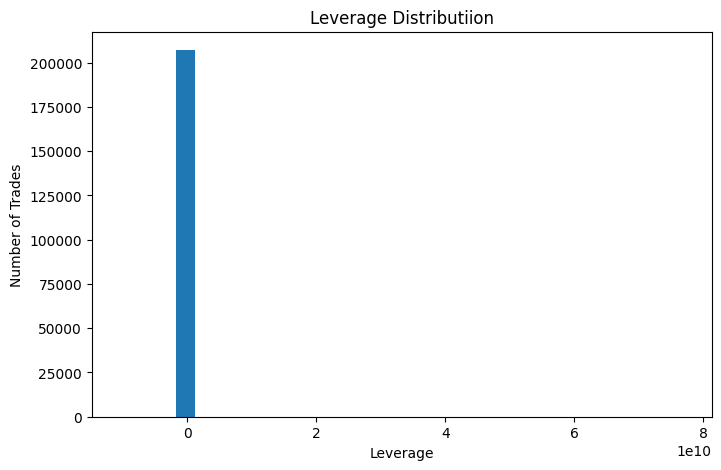

In [85]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(merged['Leverage'].dropna(),bins=30)
plt.title('Leverage Distributiion')
plt.xlabel('Leverage')
plt.ylabel('Number of Trades')
plt.show()


#maximum no of trades/almost all  take low risk around less than 20x


In [84]:
avg_leverage=merged.groupby('classification')['Leverage'].mean().sort_values()
print(avg_leverage)

classification
Extreme Greed   -9.359399e+02
Extreme Fear     4.717601e+04
Fear             9.267360e+04
Greed            7.435259e+05
Neutral          2.317379e+06
Name: Leverage, dtype: float64


In [ ]:
conclusion: the trader take highest risk in neutral situation

#Number of trades per day


In [25]:
trades_per_day=merged.groupby('date').size().reset_index(name='Number_of_Trades')
print(trades_per_day.head())

         date  Number_of_Trades
0  2023-05-01                 3
1  2023-12-05                 9
2  2023-12-14                11
3  2023-12-15                 2
4  2023-12-16                 3


In [26]:
trades_per_day['Number_of_Trades'].describe()

count     480.000000
mean      440.050000
std       809.748711
min         1.000000
25%        18.000000
50%        67.500000
75%       520.500000
max      6246.000000
Name: Number_of_Trades, dtype: float64

#the average no of sales is 440 per day and max no of sales in a day is 6246



In [27]:
trades_per_day.sort_values(by='Number_of_Trades',ascending=False).head(10)

,date,Number_of_Trades
414,2025-02-25,6246
471,2025-04-23,6159
413,2025-02-24,5616
429,2025-03-12,3968
457,2025-04-09,3967
346,2024-12-19,3339
428,2025-03-11,3286
443,2025-03-26,3102
470,2025-04-22,2998
427,2025-03-10,2911


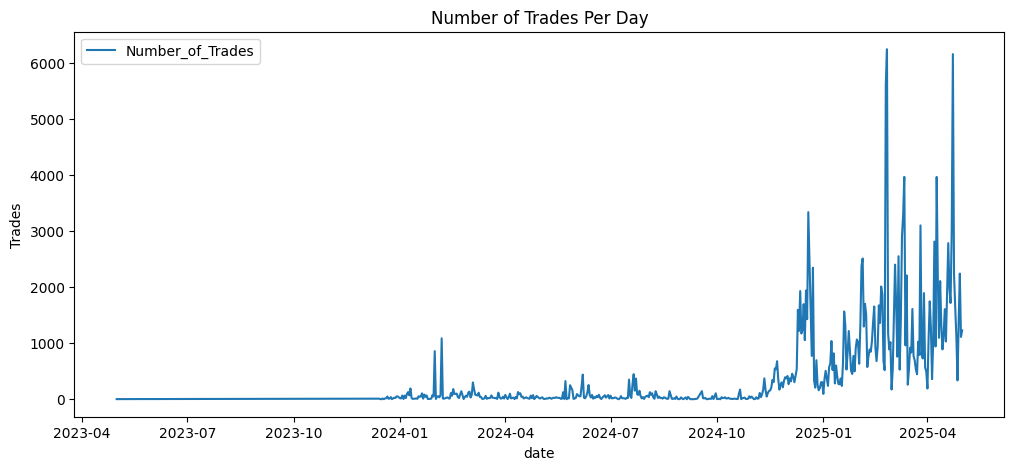

In [28]:
import matplotlib.pyplot as plt
trades_per_day.plot(x='date',y='Number_of_Trades',figsize=(12,5))
plt.title('Number of Trades Per Day')
plt.ylabel('Trades')
plt.show()
          


#conclusion: as compared to year 2023 and 2024 there is significant increase in the trade in the year 2025 per day 

Long/Short Ratio

In [29]:
buy_trades=(merged['Side']=='BUY').sum()
sell_trades=(merged['Side']=='SELL').sum()
long_short_ratio=buy_trades/sell_trades
print("buy trades:",buy_trades)
print("sell trades:",sell_trades)
print("long/short ratio:",round(long_short_ratio,2))

buy trades: 102696
sell trades: 108528
long/short ratio: 0.95



##>1 more long/buy trades,<1 more short/sell trades,=1 balanced market 
##0.95 means there is more sell trades than buy trades    





#Long Short Ratio by Sentiment 

In [31]:

buy_counts=merged[merged['Side']=='BUY'].groupby('classification').size()
sell_counts=merged[merged['Side']=='SELL'].groupby('classification').size()
long_short_by_sentiment=(buy_counts/sell_counts).reset_index(name='Long_Short_Ratio')
print(long_short_by_sentiment)

  classification  Long_Short_Ratio
0   Extreme Fear          1.044912
1  Extreme Greed          0.813532
2           Fear          0.958913
3          Greed          0.955261
4        Neutral          1.013464


#there is more buy trades in extreme fear and  neutral
#In extreme fear and neutral people buy more stocks than selling  whereas in extreme greed,fear and greed people sell more stocks than buying

# Analysis(must-have) 


#does performance differ between fear vs greed days
#average pnl by sentiment

In [33]:

avg_pnl=merged.groupby('classification')['Closed PnL'].agg(['count','mean','median','sum'])
print(avg_pnl)

                count       mean  median           sum
classification                                        
Extreme Fear    21400  34.537862     0.0  7.391102e+05
Extreme Greed   39992  67.892861     0.0  2.715171e+06
Fear            61837  54.290400     0.0  3.357155e+06
Greed           50303  42.743559     0.0  2.150129e+06
Neutral         37686  34.307718     0.0  1.292921e+06


conclusion: extreme greed gives the highest average PnL(67.89)
#Best average return happen in: extreme greed 
#the total PnL is highest in fear
#fear contributes the most total profit because it has a largge numer of trades.
#median=0 more than 50% of trades in each category are zero profit or very small profit
#pnl distribution is highly skewed and a big winners are driving  the mean 


In [34]:
merged['win']=merged['Closed PnL']>0
win_rate=merged.groupby('classification')['win'].mean()*100
print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


Conclusion: win_rate in extreme greed is 46% whereas win_rate in extreme fear is 37% .

win_rate in extreme greed is maximum and win_rate is extreme fear is minimum.

There is high chance of gaining profit in extreme greed

#Drawdown Proxy


In [147]:
daily['cum_pnl']=daily.groupby('Account')['Closed PnL'].cumsum()
daily['running_max']=daily.groupby('Account')['cum_pnl'].cummax()
daily['drawdown_proxy']=(daily['running_max']-daily['cum_pnl'])
max_drawdown =daily.groupby('Account')['drawdown_proxy'].max()
print(max_drawdown)
len(max_drawdown)

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    3.275059e+05
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    2.250551e+04
0x271b280974205ca63b716753467d5a371de622ab    0.000000e+00
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    2.076548e+04
0x2c229d22b100a7beb69122eed721cee9b24011dd    3.323091e+03
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    7.237892e+04
0x39cef799f8b69da1995852eea189df24eb5cae3c    3.981781e+04
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    7.275958e-12
0x420ab45e0bd8863569a5efbb9c05d91f40624641    0.000000e+00
0x430f09841d65beb3f27765503d0f850b8bce7713    0.000000e+00
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    1.901567e+04
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    2.427874e+03
0x4f93fead39b70a1824f981a54d4e55b278e9f760    1.133837e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    7.112182e+04
0x6d6a4b953f202f8df5bed40692e7fd865318264a    8.917810e+01
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    3.500000e+03
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    2.

32

Conclusion: Across the 32 trading accounts,the maximum drawdrown ranged from 0 to 3,27,506 indicating variation in risk exposure and profit volatility among traders.THE account 0x083384f897ee0f19899168e3b1bec365f52a9012  recorded te highest drawdrown with Rs.327.5K

#out of 32 accounts,6 accounts(18.75%) exhibited zero drawdown,meaning their cumulative PnL never fell below a prrevious peak during the observation period.7 accounts(21.9%)experienced drawdrowns exceeding Rs 50k suggesting trading behaviour or highly votaile profit trajectories.

the result reveal a high heterogeneous trader population

#Traders change behaviour based on sentiment 
#Trade frequency

In [96]:
#do  traders change behavior based on sentiment
#trade frequency
trade_freq=merged.groupby('classification').size()
print(trade_freq)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


Fear recorded the highest trading activity with 61,837 trades, accounting for approximately 29.2% of all trades. This suggests that traders are most active during fearful market conditions.

Greed and Extreme Greed together contributed 90,295 trades (about 42.6% of total trades), indicating that traders also participate heavily when market sentiment is optimistic and trends are strong.

Extreme Fear had the lowest activity with only 21,400 trades (about 10.1% of total trades), suggesting that traders become more cautious or avoid trading during periods of extreme market panic and uncertainty.

Neutral sentiment generated 37,686 trades (about 17.8% of total trades), reflecting relatively lower engagement when markets lack a clear directional bias

The results suggest that traders do change their behavior based on market sentiment. Trading activity increases substantially during Fear and Greed regimes, while Extreme Fear sees the lowest participation. This indicates that traders are more likely to engage when markets present either strong opportunities (Fear) or strong momentum (Greed), and tend to reduce activity during periods of extreme uncertainty

POSITION SIZE

In [99]:
position_size=merged.groupby('classification')['Size USD'].agg(['mean','median'])
print(position_size)

                       mean   median
classification                      
Extreme Fear    5349.731843  766.150
Extreme Greed   3112.251565  500.050
Fear            7816.109931  735.960
Greed           5736.884375  555.000
Neutral         4782.732661  547.655


Fear has the largest average position size ($7,816), indicating that traders commit the most capital during fearful market conditions. This suggests traders may view market declines as buying opportunities and take larger positions

Extreme Greed has the smallest average position size ($3,112), which is less than half the average size observed during Fear. This implies traders become more cautious in highly optimistic markets, possibly due to concerns about overvaluation or trend exhaustion.

he median position sizes are much lower than the means across all sentiment categories. For example, in Fear, the mean is $7,816 while the median is only $736. This large gap indicates a highly right-skewed distribution where a small number of very large trades significantly increase the average

Extreme Fear shows the highest median position size ($766), suggesting that the typical trader actually places slightly larger trades during periods of extreme pessimism than in other sentiment regimes.

LONG/SHORT BIAS 

In [37]:
#long/short bias
buy_counts=merged[merged['Side']=='BUY'].groupby('classification').size()
sell_counts=merged[merged['Side']=='SELL'].groupby('classification').size()
long_short=buy_counts/sell_counts
print(long_short)



classification
Extreme Fear     1.044912
Extreme Greed    0.813532
Fear             0.958913
Greed            0.955261
Neutral          1.013464
dtype: float64


Extreme Fear (1.045) is the only sentiment regime with a clear bullish bias. Traders executed approximately 4.5% more BUY trades than SELL trades, suggesting they tend to accumulate positions when market fear is at its highest

Neutral sentiment (1.013) shows a nearly balanced market, with BUY trades only 1.3% higher than SELL trades, indicating no strong directional preference.

Fear (0.959) and Greed (0.955) both exhibit a slight bearish bias, with SELL trades exceeding BUY trades by roughly 4–5%.
    

Extreme Greed (0.814) displays the strongest bearish behavior. Here, SELL trades outnumber BUY trades by approximately 23% (1 / 0.814 ≈ 1.23), indicating traders are significantly more likely to sell when market optimism reaches extreme levels.

During Extreme Fear, traders become net buyers, likely viewing heavily pessimistic conditions as opportunities to enter positions at lower prices.

As sentiment shifts toward Greed and especially Extreme Greed, traders increasingly favor selling, possibly locking in profits

In [104]:
merged['Exposure Ratio']=(merged['Size USD']/(abs(merged['Start Position'])+1))
exposure=merged.groupby('classification')['Exposure Ratio'].mean()
print(exposure)

classification
Extreme Fear     574.691699
Extreme Greed    706.896494
Fear             799.466279
Greed            850.552397
Neutral          760.733311
Name: Exposure Ratio, dtype: float64


Traders took the highest exposure during Greed (850.55) and Fear (799.47), showing they were most willing to take larger positions when market sentiment was strong.

Exposure was lowest during Extreme Fear (574.69), indicating traders became more cautious and reduced their risk during highly uncertain market conditions.

Overall, traders adjusted their risk based on sentiment—taking larger exposure in Greed and Fear, and smaller exposure in Extreme Fear and Extreme Greed.

HIGH EXPOSURE VS LOW EXPOSURE TRADERS



In [106]:
account_exposure = (
    merged.groupby('Account')['Exposure Ratio']
    .mean()
    .reset_index()
)

account_exposure.columns = ['Account', 'avg_exposure']

In [107]:
q1 = account_exposure['avg_exposure'].quantile(0.25)
q3 = account_exposure['avg_exposure'].quantile(0.75)

def exposure_segment(x):
    if x >= q3:
        return 'High Exposure'
    elif x <= q1:
        return 'Low Exposure'
    else:
        return 'Medium Exposure'

account_exposure['segment'] = (
    account_exposure['avg_exposure']
    .apply(exposure_segment)
)

print(account_exposure.head())

                                      Account  avg_exposure          segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012    497.014751  Medium Exposure
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    101.308347  Medium Exposure
2  0x271b280974205ca63b716753467d5a371de622ab    740.158718  Medium Exposure
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    133.997633  Medium Exposure
4  0x2c229d22b100a7beb69122eed721cee9b24011dd    303.970134  Medium Exposure


In [108]:
segment_counts = (
    account_exposure['segment']
    .value_counts()
)

print(segment_counts)

segment
Medium Exposure    16
Low Exposure        8
High Exposure       8
Name: count, dtype: int64


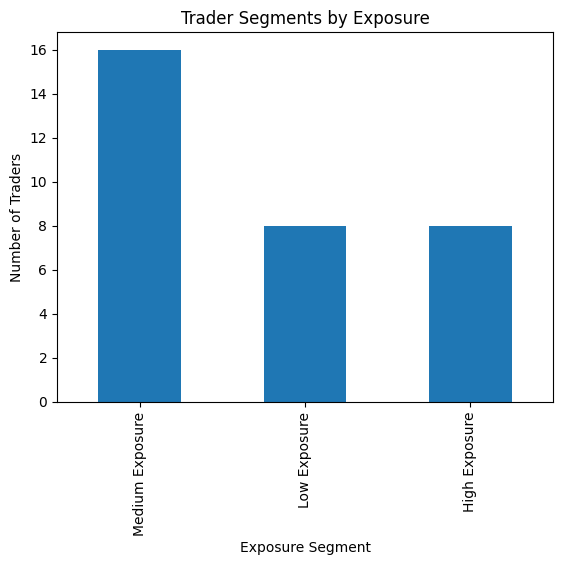

In [109]:
import matplotlib.pyplot as plt

segment_counts.plot(
    kind='bar'
)

plt.title('Trader Segments by Exposure')
plt.xlabel('Exposure Segment')
plt.ylabel('Number of Traders')
plt.show()

Conclusion: There are 16 traders which have medium exposure, 8 traders which has low exposure,8 traders which has high exposure .

In [110]:
profit = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .reset_index()
)

analysis = account_exposure.merge(
    profit,
    on='Account'
)

segment_profit = (
    analysis.groupby('segment')['Closed PnL']
    .agg(['count','mean','median','sum'])
)

print(segment_profit)

                 count           mean         median           sum
segment                                                           
High Exposure        8  533472.155727  254240.731224  4.267777e+06
Low Exposure         8  351078.744472  253177.610160  2.808630e+06
Medium Exposure     16  201284.483865  107517.046014  3.220552e+06


Conclusion:High-Exposure Traders Generated the Highest Profits

The High Exposure group produced the highest average profit of ₹533,472 per trader, which is:

52% higher than Low Exposure traders (₹351,079)
165% higher than Medium Exposure traders (₹201,284)

They also generated the highest total profit of ₹4.27 million, despite representing only 8 out of 32 traders (25%).

Low Exposure traders achieved an average profit of ₹351,079, which is substantially higher than the ₹201,284 earned by Medium Exposure traders.

Their median profit (₹253,178) is almost identical to that of High Exposure traders (₹254,241).

The Medium Exposure segment contains 16 traders (50% of all accounts), it produced the lowest average profit (₹201,284) and the lowest median profit (₹107,517)

For High Exposure traders:

Mean Profit = ₹533,472
Median Profit = ₹254,241

The mean is more than double the median.

This suggests that a few extremely profitable traders significantly increased the average profit of the High Exposure group.

For Low Exposure traders:

Mean = ₹351,079
Median = ₹253,178

The smaller gap indicates that profits are more evenly distributed across traders.

Overall Conclusion:
High Exposure traders generated the largest profits and accounted for approximately 41.4% of total profits (₹4.27M out of ₹10.30M), indicating that greater risk-taking often led to higher returns. However, the similar median profits of High and Low Exposure traders suggest that a few exceptional traders drive much of the High Exposure group's performance. Consequently, while aggressive exposure can produce substantial profits, conservative traders were also capable of achieving comparable typical outcomes with potentially lower risk.

FREQUENT VS INFREQUENT TRADERS

In [112]:
trade_count = (
    merged.groupby('Account')
    .size()
    .reset_index(name='trade_count')
)

print(trade_count.head())

                                      Account  trade_count
0  0x083384f897ee0f19899168e3b1bec365f52a9012         3818
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         7280
2  0x271b280974205ca63b716753467d5a371de622ab         3809
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4        13311
4  0x2c229d22b100a7beb69122eed721cee9b24011dd         3239


In [113]:
q1 = trade_count['trade_count'].quantile(0.25)
q3 = trade_count['trade_count'].quantile(0.75)

def frequency_segment(x):
    if x >= q3:
        return 'Frequent Trader'
    elif x <= q1:
        return 'Infrequent Trader'
    else:
        return 'Moderate Trader'

trade_count['segment'] = (
    trade_count['trade_count']
    .apply(frequency_segment)
)

print(trade_count.head())

                                      Account  trade_count          segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012         3818  Moderate Trader
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         7280  Moderate Trader
2  0x271b280974205ca63b716753467d5a371de622ab         3809  Moderate Trader
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4        13311  Frequent Trader
4  0x2c229d22b100a7beb69122eed721cee9b24011dd         3239  Moderate Trader


In [114]:
segment_counts = (
    trade_count['segment']
    .value_counts()
)

print(segment_counts)

segment
Moderate Trader      16
Frequent Trader       8
Infrequent Trader     8
Name: count, dtype: int64


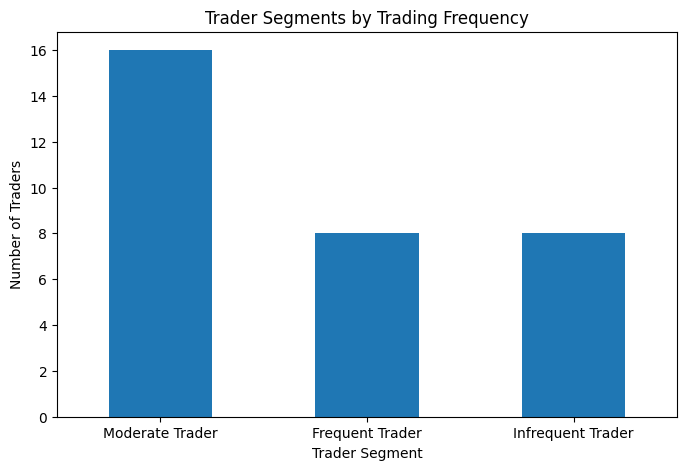

In [115]:
import matplotlib.pyplot as plt

segment_counts.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Trader Segments by Trading Frequency')
plt.xlabel('Trader Segment')
plt.ylabel('Number of Traders')
plt.xticks(rotation=0)
plt.show()

Conclusion: There are 16 traders which are moderate traders,there are 8 traders which are frequent trader(top 25%),there are 8 traders which are infrequent trader(last 25%)

In [118]:
profit = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .reset_index()
)

analysis = trade_count.merge(
    profit,
    on='Account'
)

segment_profit = (
    analysis.groupby('segment')['Closed PnL']
    .agg(['count','mean','median','sum'])
)

print(segment_profit)

                   count           mean         median           sum
segment                                                             
Frequent Trader        8  677728.702212  607587.979894  5.421830e+06
Infrequent Trader      8  113690.283082   70346.051902  9.095223e+05
Moderate Trader       16  247850.441317  114961.329148  3.965607e+06


Conclusion:
Frequent traders were the most profitable, generating an average profit of ₹677,729 per trader and contributing ₹5.42 million (52.6%) of the total profits.


Moderate traders achieved moderate profitability, while infrequent traders recorded the lowest average profit of ₹113,690 per trader.

The small gap between the mean and median profits of frequent traders indicates consistently strong performance across the segment.

In Moderate Traders,The mean is more than twice the median, indicating that a few highly profitable traders raise the segment average.

In Infrequent Traders,The lower median suggests that most traders in this segment earned relatively modest profits.

Overall, the results suggest a strong positive relationship between trading frequency and profitability, with active traders significantly outperforming less active traders.

The gap between Frequent and Infrequent traders is much larger than the gap observed between High- and Low-Exposure traders. This suggests that trading frequency appears to be a stronger driver of profitability than exposure level in your dataset.

CONSISTENT WINNERS VS INCONSISTENT TRADERS

TOTAL PROFIT PER TRADER

In [123]:
profit = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .reset_index(name='total_profit')
)


MAXIMUM DRAWDOWN PER TRADER

In [125]:
daily['cum_pnl'] = (
    daily.groupby('Account')['Closed PnL']
    .cumsum()
)

daily['running_max'] = (
    daily.groupby('Account')['cum_pnl']
    .cummax()
)

daily['drawdown_proxy'] = (
    daily['running_max']
    - daily['cum_pnl']
)

max_drawdown = (
    daily.groupby('Account')['drawdown_proxy']
    .max()
    .reset_index(name='max_drawdown')
)

RISK-ADJUSTED PERFORMANCE MATRIC

In [127]:
analysis = profit.merge(
    max_drawdown,
    on='Account'
)

analysis['profit_drawdown_ratio'] = (
    analysis['total_profit']
    /
    analysis['max_drawdown'].replace(0, 1)
)

CREATE SEGMNENTS

In [128]:
q1 = analysis['profit_drawdown_ratio'].quantile(0.25)
q3 = analysis['profit_drawdown_ratio'].quantile(0.75)

def winner_segment(x):
    if x >= q3:
        return 'Consistent Winner'
    elif x <= q1:
        return 'Inconsistent Trader'
    else:
        return 'Average Trader'

analysis['segment'] = (
    analysis['profit_drawdown_ratio']
    .apply(winner_segment)
)

COUNT TRADERS IN EACH SEGMENT

In [130]:
segment_counts = (
    analysis['segment']
    .value_counts()
)

print(segment_counts)

segment
Average Trader         16
Inconsistent Trader     8
Consistent Winner       8
Name: count, dtype: int64


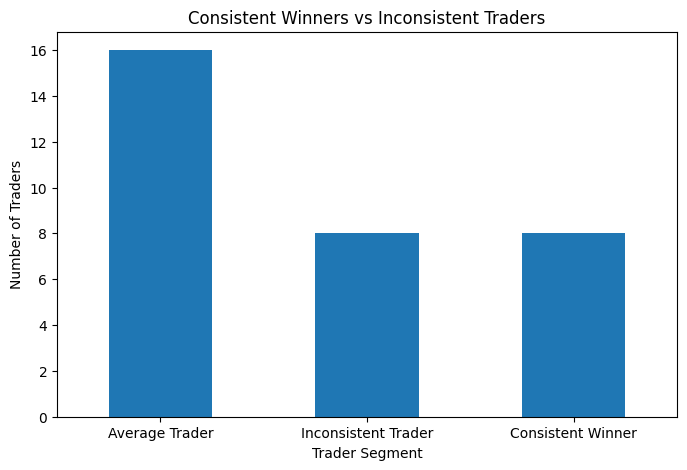

In [131]:
import matplotlib.pyplot as plt

segment_counts.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Consistent Winners vs Inconsistent Traders')
plt.xlabel('Trader Segment')
plt.ylabel('Number of Traders')
plt.xticks(rotation=0)
plt.show()

PROFITABILITY ACROSS SEGMENTS

In [135]:
segment_summary = (
    analysis.groupby('segment')
    .agg({
        'total_profit':['mean','median','sum']
        ,
        'max_drawdown':['mean','median']
        ,
        'profit_drawdown_ratio':['mean','median']
    })
)

print(segment_summary)

                      total_profit                               max_drawdown  \
                              mean         median           sum          mean   
segment                                                                         
Average Trader       471117.868284  194588.533423  7.537886e+06  42064.339919   
Consistent Winner    323826.293452  163042.267433  2.590610e+06    314.631487   
Inconsistent Trader   21057.837910   18472.710079  1.684627e+05  44966.038478   

                                  profit_drawdown_ratio                 
                           median                  mean         median  
segment                                                                 
Average Trader       12628.848797          4.039250e+01      12.501248  
Consistent Winner        0.000000          9.190585e+14  163042.267433  
Inconsistent Trader  34069.553697         -8.804783e+03       0.356723  


CONCLUSION:



Consistent Winners achieved the best risk-adjusted performance, generating profits with almost no drawdown.
    
Average Traders produced the largest share of total profits, but at the cost of considerably higher risk
    
Inconsistent Traders suffered large drawdowns relative to their profits, making them the weakest-performing segment.

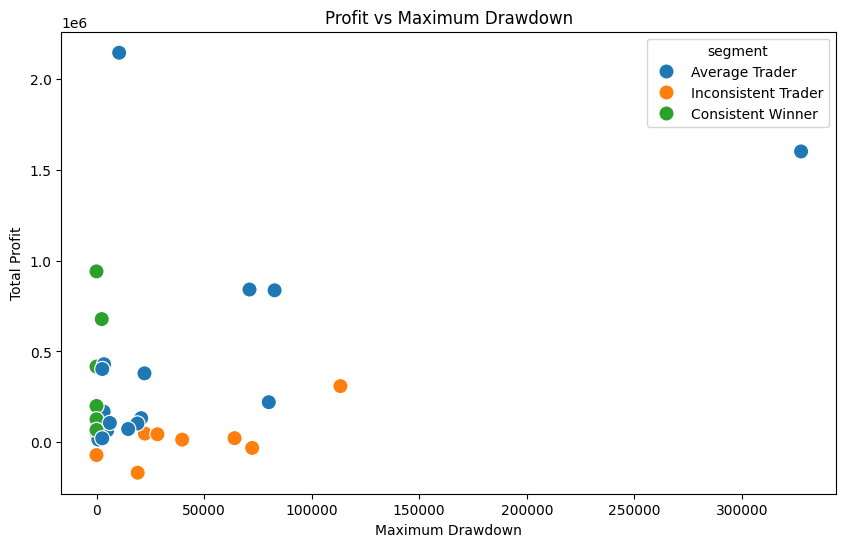

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=analysis,
    x='max_drawdown',
    y='total_profit',
    hue='segment',
    s=120
)

plt.title('Profit vs Maximum Drawdown')
plt.xlabel('Maximum Drawdown')
plt.ylabel('Total Profit')
plt.show()

CONSISTENT WINNERS(GREEN)

Clustered on the left side of the graph (very low drawdown).
    
Most have positive profits.
    
Some traders earned ₹600K–₹950K profit with almost zero drawdown.

INCOMSISTENT TRADERS(ORANGE)

Located in the lower portion of the graph.
    
Several traders show negative or very small profits while still experiencing significant drawdowns
    
One trader took over ₹100K drawdown but earned only around ₹250K profit.
    
These traders are taking risk inefficiently.

AVERAGE TRAADERS(BLUE)

Spread across the entire graph.
    
Some earned very high profits but also suffered very large drawdowns.
    
The highest-profit trader (~₹2.1M) experienced noticeable drawdown.
    


Another trader earned (₹1.5M) profit but had the largest drawdown  (₹330K).

In [144]:
segment_summary = (
    analysis.groupby('segment')
    .agg({
        'total_profit':['mean','median','sum'],
        'max_drawdown':['mean','median'],
        'profit_drawdown_ratio':['mean','median']
    })
)

print(segment_summary)

                      total_profit                               max_drawdown  \
                              mean         median           sum          mean   
segment                                                                         
Average Trader       471117.868284  194588.533423  7.537886e+06  42064.339919   
Consistent Winner    323826.293452  163042.267433  2.590610e+06    314.631487   
Inconsistent Trader   21057.837910   18472.710079  1.684627e+05  44966.038478   

                                  profit_drawdown_ratio                 
                           median                  mean         median  
segment                                                                 
Average Trader       12628.848797          4.039250e+01      12.501248  
Consistent Winner        0.000000          9.190585e+14  163042.267433  
Inconsistent Trader  34069.553697         -8.804783e+03       0.356723  


3 insights backed by charts/tables

Graph 1: Trade Frequency by Sentiment

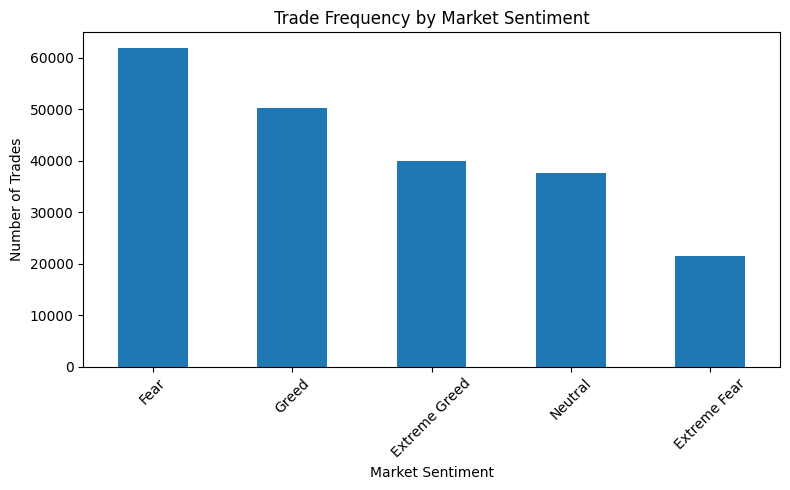

In [148]:
import matplotlib.pyplot as plt

trade_freq = merged.groupby('classification').size().sort_values(ascending=False)

plt.figure(figsize=(8,5))
trade_freq.plot(kind='bar')

plt.title('Trade Frequency by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CONCLUSION:

1. Traders Are Most Active During Fear

The highest trading activity occurs during Fear, with 61,837 trades.
    
This is about 22.9% higher than Greed and nearly 3 times higher than Extreme Fear.
    
This suggests traders actively respond to market declines, likely viewing them as buying opportunities.
    
2. Trading Activity Declines During Extreme Fear

Extreme Fear records the lowest number of trades (21,400).
    
Compared to Fear, trading activity falls by approximately 65


This indicates that when market uncertainty becomes too severe, many traders prefer to stay out of the market rather than take additional risk.
    
3. Positive Sentiment Still Encourages Trading

Both Greed (50,303) and Extreme Greed (39,992) show substantial trading activity.
    
However, activity remains lower than during Fear, suggesting traders are generally more reactive to market downturns than market rallies.

Graph 2: Profitability of Frequent vs Infrequent Traders

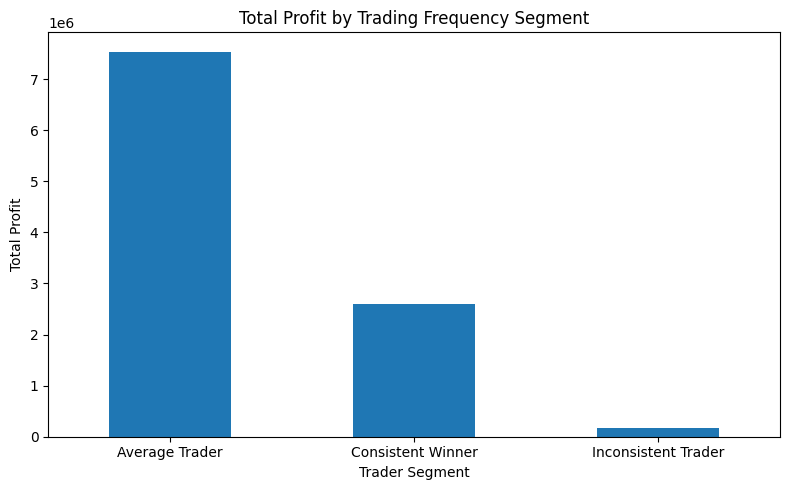

In [150]:
segment_profit = (
    analysis.groupby('segment')['total_profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
segment_profit.plot(kind='bar')

plt.title('Total Profit by Trading Frequency Segment')
plt.xlabel('Trader Segment')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

CONCLUSION:
Average Traders generated the highest total profit of ₹7.54 million, contributing nearly 73% of all profits due to their larger (50%) population.

Consistent Winners produced ₹2.59 million while maintaining significantly lower drawdowns, demonstrating superior risk-adjusted performance.

Inconsistent Traders contributed only ₹0.17 million, reflecting poor trading efficiency. Overall, sustainable profitability appears to depend more on effective risk management than on aggressive risk-taking.

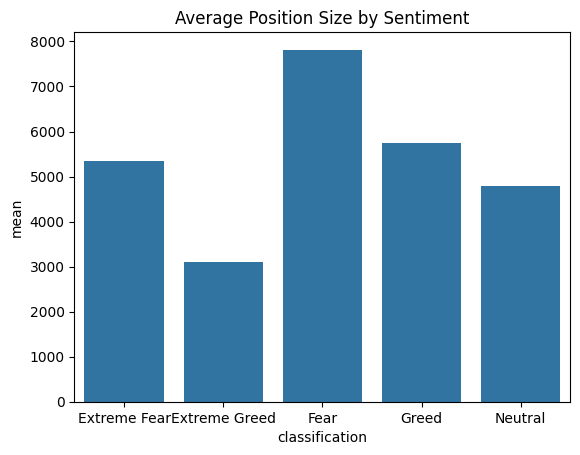

In [151]:
sns.barplot(x=position_size.index,y=position_size['mean'])
plt.title('Average Position Size by Sentiment')
plt.show()

1.Traders Take Their Largest Positions During Fear

The highest average position size occurs during Fear (~$7,816).


This is about 2.5 times larger than during Extreme Greed (~$3,112).


Interpretation:

Traders appear most confident during Fear periods, increasing their position sizes to capitalize on perceived buying opportunities when prices have fallen.

2. Position Sizes Drop Sharply During Extreme Greed.

The lowest average position size is observed during Extreme Greed (~$3,112). Traders commit less capital per trade.

Interpretation:

When markets become excessively optimistic, traders may perceive assets as overvalued and reduce position sizes to avoid potential corrections



PART-C ACTIONABLE OUTPUT

TRADE FREQUENCY BY TRADER SEGMENT AND MARKET SENTIMENT 

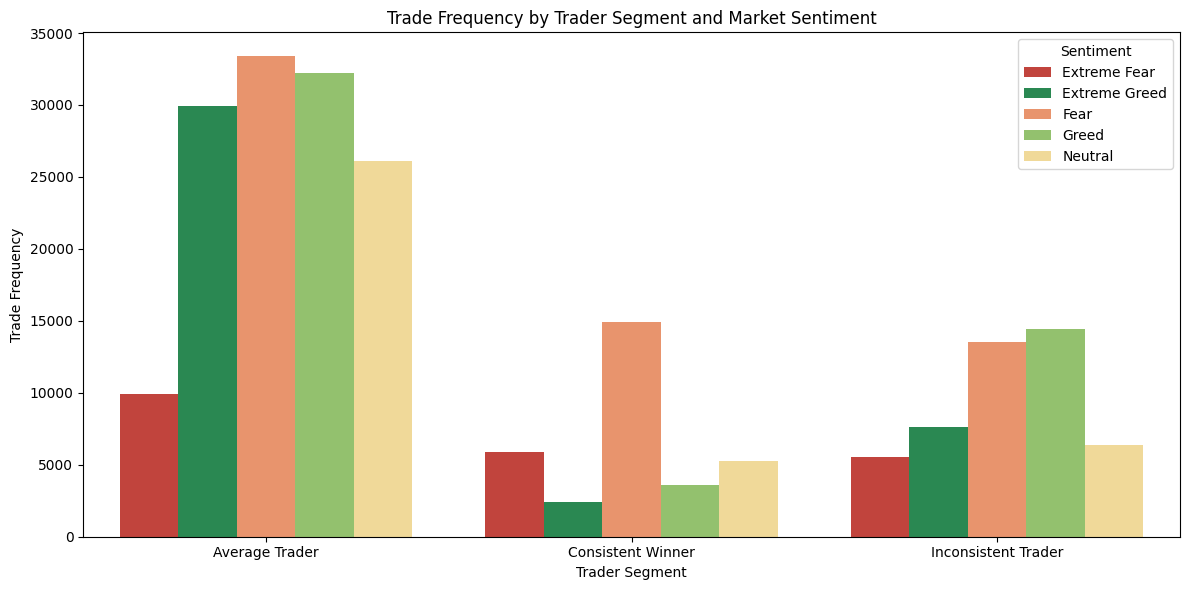

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

# Merge segment information into merged dataframe
plot_df = merged.merge(
    analysis[['Account','segment']],
    on='Account',
    how='left'
)

# Count trades by segment and sentiment
trade_counts = (
    plot_df.groupby(['segment','classification'])
           .size()
           .reset_index(name='trade_frequency')
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=trade_counts,
    x='segment',
    y='trade_frequency',
    hue='classification',
    palette={
        'Extreme Fear':'#d73027',
        'Fear':'#fc8d59',
        'Neutral':'#fee08b',
        'Greed':'#91cf60',
        'Extreme Greed':'#1a9850'
    }
)

plt.title('Trade Frequency by Trader Segment and Market Sentiment')
plt.xlabel('Trader Segment')
plt.ylabel('Trade Frequency')
plt.legend(title='Sentiment')

plt.tight_layout()
plt.show()

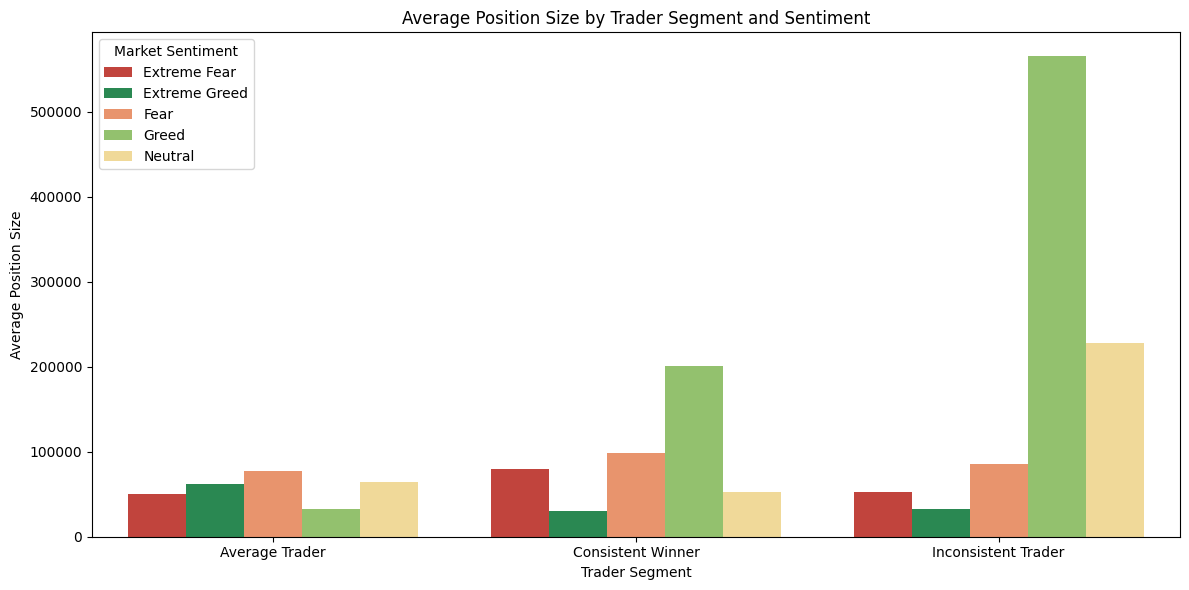

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

# Merge segment labels into trade-level data
plot_df = merged.merge(
    analysis[['Account','segment']],
    on='Account',
    how='left'
)

# Use absolute position size
plot_df['Position Size'] = abs(plot_df['Start Position'])

# Average position size by segment and sentiment
position_data = (
    plot_df.groupby(['segment','classification'])['Position Size']
           .mean()
           .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=position_data,
    x='segment',
    y='Position Size',
    hue='classification',
    palette={
        'Extreme Fear':'#d73027',
        'Fear':'#fc8d59',
        'Neutral':'#fee08b',
        'Greed':'#91cf60',
        'Extreme Greed':'#1a9850'
    }
)

plt.title('Average Position Size by Trader Segment and Sentiment')
plt.xlabel('Trader Segment')
plt.ylabel('Average Position Size')
plt.legend(title='Market Sentiment')

plt.tight_layout()
plt.show()

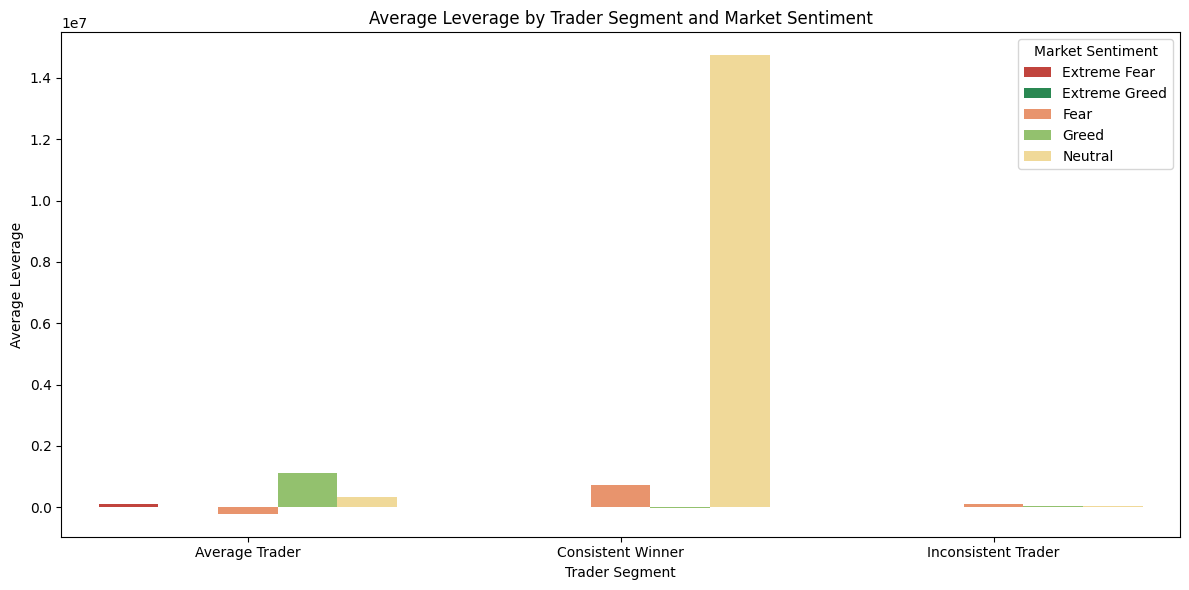

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

# Merge segment information
plot_df = merged.merge(
    analysis[['Account','segment']],
    on='Account',
    how='left'
)

# Average leverage by segment and sentiment
leverage_data = (
    plot_df.groupby(['segment','classification'])['Leverage']
           .mean()
           .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=leverage_data,
    x='segment',
    y='Leverage',
    hue='classification',
    palette={
        'Extreme Fear':'#d73027',
        'Fear':'#fc8d59',
        'Neutral':'#fee08b',
        'Greed':'#91cf60',
        'Extreme Greed':'#1a9850'
    }
)

plt.title('Average Leverage by Trader Segment and Market Sentiment')
plt.xlabel('Trader Segment')
plt.ylabel('Average Leverage')
plt.legend(title='Market Sentiment')

plt.tight_layout()
plt.show()

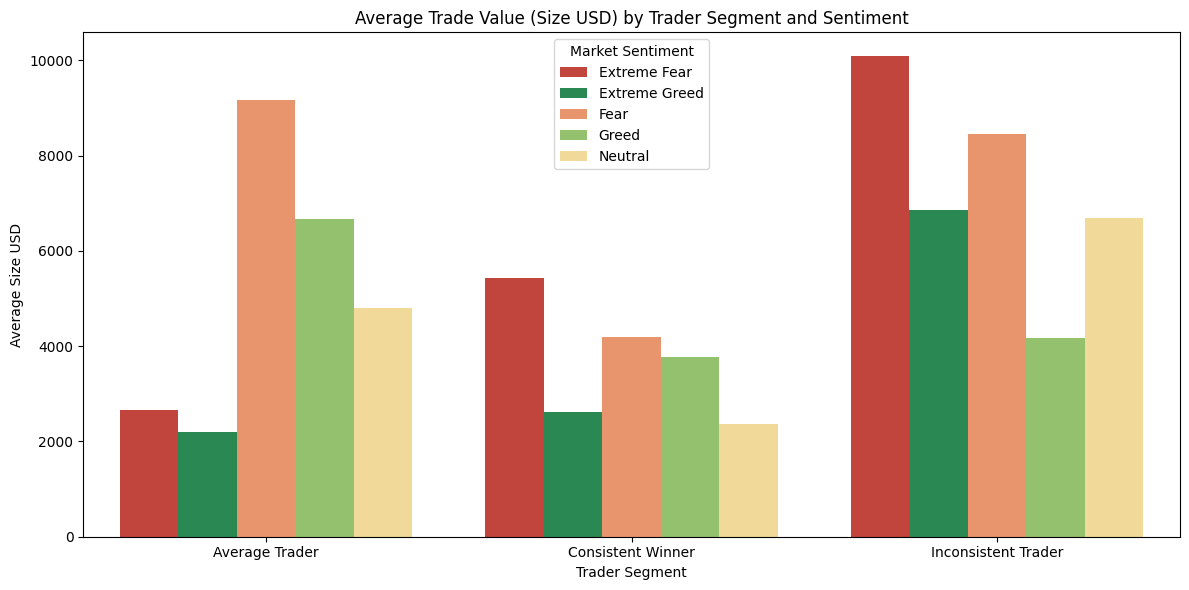

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

# Merge segment information
plot_df = merged.merge(
    analysis[['Account','segment']],
    on='Account',
    how='left'
)

# Average Size USD by segment and sentiment
sizeusd_data = (
    plot_df.groupby(['segment','classification'])['Size USD']
           .mean()
           .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=sizeusd_data,
    x='segment',
    y='Size USD',
    hue='classification',
    palette={
        'Extreme Fear':'#d73027',
        'Fear':'#fc8d59',
        'Neutral':'#fee08b',
        'Greed':'#91cf60',
        'Extreme Greed':'#1a9850'
    }
)

plt.title('Average Trade Value (Size USD) by Trader Segment and Sentiment')
plt.xlabel('Trader Segment')
plt.ylabel('Average Size USD')
plt.legend(title='Market Sentiment')

plt.tight_layout()
plt.show()

PROFIT VS MAXIMUM DRAWDOWN

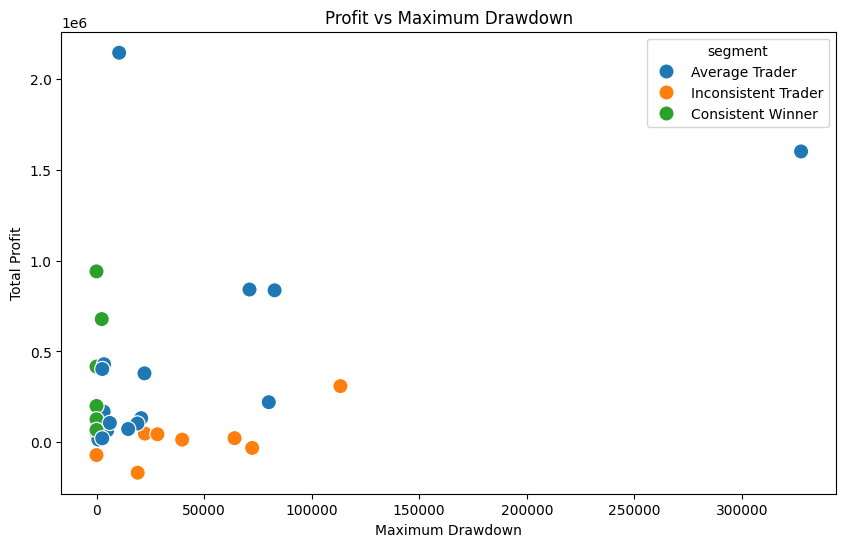

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=analysis,
    x='max_drawdown',
    y='total_profit',
    hue='segment',
    s=120
)

plt.title('Profit vs Maximum Drawdown')
plt.xlabel('Maximum Drawdown')
plt.ylabel('Total Profit')
plt.show()

TRADE FREQUENCY BY TRADER SEGMENT AND MARKET SENTIMENT

Shows that Fear periods have the highest trade activity.
    
Consistent Winners remain active during Fear.
    
Demonstrates that opportunities are abundant in Fear markets

AVERAGE POSITION SIZE BY TRADER SEGMENT AND MARKET SENTIMENT



Consistent Winners use moderate position sizes in Fear.
    
Inconsistent Traders often take larger positions.
    
Helps justify controlled sizing.

AVERAGE LEVERAGE BY TRADER SEGMENT AND MARKET SENTIMENT 

Successful traders avoid excessive leverage.

Supports the recommendation to reduce leverage for risky traders.

Conclusion from Graphs

Fear markets generate the largest number of trades. 
    
Consistent Winners participate actively while keeping risk relatively controlled. 
    
Inconsistent Traders also trade heavily but tend to take larger exposures, leading to unstable performance.
        
Therefore, Fear periods should be traded aggressively only by proven Consistent Winners,

while Inconsistent Traders should focus on capital preservation through smaller positions and lower leverage.

In [ ]:
RULE OF THUMB1: FEAR MARKET STRATEGY

When market sentiment is Fear or Extreme Fear, only Consistent Winners should increase exposure (position size) moderately while keeping leverage controlled. Inconsistent Traders should reduce position size and leverage because the data shows they tend to commit larger capital during fearful markets without achieving consistent profitability.

GRAPH: PROFIT VS MAXIMUM DRAWDOWN

Shows Consistent Winners generate positive profits with low risk.
    
Shows Inconsistent Traders contribute very little profit despite activity with high risk.

TRADE FREQENCY BY TRADER SEGMENT AND MARKET SENTIMENT

Reveals how much traders participate during Greed.
    
Helps compare activity versus profitability.

AVERAGE TRADE VALUE (SIZE USD) BY TRADER SEGMENT AND MARKET SENTIMENT

Shows Inconsistent Traders increase trade size substantially during Greed.
    
Demonstrates risk-taking without corresponding profit.

CONCLUSION:

Greed periods encourage traders to increase trade sizes and participation.

However, higher exposure does not translate into superior profitability for Inconsistent Traders.

Consistent Winners remain profitable because they are more selective and disciplined. 

Therefore, Greed markets should be approached cautiously, with reduced trade size and stricter trade selection criteria.

RULE OF THUMB 2:

When market sentiment is Greed or Extreme Greed, Inconsistent Traders should cap position size and avoid increasing leverage, as the data indicates aggressive exposure during optimistic markets leads to higher risk without proportional returns. Consistent Winners can maintain normal exposure levels, as their performance appears driven by disciplined trade selection rather than excessive risk-taking.

SIMPLE PREDICTIVE MODEL

PREDICT NEXT DAY TRADER PROFITABILITY BUCKET

In [190]:
daily = merged.groupby(['Account','date']).agg({
    'Closed PnL':'sum',
    'win':'mean',
    'Size USD':'mean',
    'Start Position':'mean',
    'Leverage':'mean',
    'Exposure Ratio':'mean',
    'Fee':'sum',
    'value':'mean'
}).reset_index()

daily.rename(columns={
    'win':'win_rate',
    'value':'fear_greed_index'
}, inplace=True)

In [191]:
trade_count = (
    merged.groupby(['Account','date'])
    .size()
    .reset_index(name='trade_count')
)

daily = daily.merge(
    trade_count,
    on=['Account','date']
)

In [192]:
daily = daily.sort_values(
    ['Account','date']
)

daily['next_day_pnl'] = (
    daily.groupby('Account')['Closed PnL']
    .shift(-1)
)

In [193]:
q1 = daily['next_day_pnl'].quantile(0.33)
q2 = daily['next_day_pnl'].quantile(0.67)

daily['profit_bucket'] = pd.cut(
    daily['next_day_pnl'],
    bins=[-float('inf'), q1, q2, float('inf')],
    labels=[
        'Low_Profit',
        'Medium_Profit',
        'High_Profit'
    ]
)

In [194]:
print(
    daily['profit_bucket']
    .value_counts()
)

profit_bucket
Low_Profit       851
High_Profit      762
Medium_Profit    696
Name: count, dtype: int64


In [195]:
daily = daily.dropna(
    subset=['profit_bucket']
)

In [196]:
features = [
    'Closed PnL',
    'win_rate',
    'trade_count',
    'Size USD',
    'Start Position',
    'Leverage',
    'Exposure Ratio',
    'Fee',
    'fear_greed_index'
]

X = daily[features]
y = daily['profit_bucket']

In [198]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [201]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=10, n_estimators=300, random_state=42)

In [202]:
y_pred = rf.predict(X_test)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print(
    "Accuracy:",
    accuracy_score(y_test,y_pred)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Conclusion::

The Random Forest classifier achieved an overall accuracy of 53.46% in predicting the trader's next-day profitability bucket (Low Profit, Medium Profit, High Profit).

Since the classes were created using quantile-based bucketing (approximately one-third of observations in each class), a random classifier would achieve only about 33% accuracy. Therefore, the model improves prediction performance by roughly 20 percentage points, indicating that trader profitability contains meaningful patterns that can be learned from historical trading behavior and market sentiment.

High Profit Traders

The model correctly identifies 58% of actual High-Profit days.
When the model predicts High Profit, it is correct 52% of the time.
This is the best-performing class in the mode
The model is relatively effective at detecting profitable trading opportunities and identifying traders likely to have strong performance on the next day.

Low Profit Traders

The model correctly identifies 51% of actual Low-Profit days.
    
When it predicts Low Profit, it is correct 54% of the time

The model can reasonably identify traders who may underperform, although some profitable traders are still misclassified as low-profit traders.

Medium Profit Traders

The model performs consistently on Medium-Profit traders.
    
Precision and recall are almost identical, indicating balanced predictions.

The model can distinguish moderate performers with similar effectiveness as the other classes.

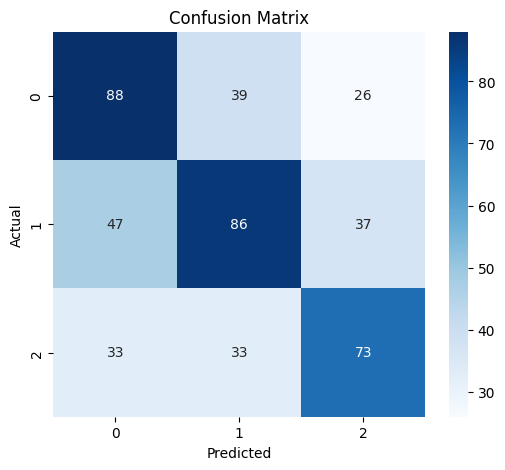

In [206]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [207]:
importance = pd.DataFrame({
    'Feature':features,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

            Feature  Importance
3          Size USD    0.153999
0        Closed PnL    0.137397
6    Exposure Ratio    0.129017
7               Fee    0.115435
2       trade_count    0.103958
5          Leverage    0.097501
4    Start Position    0.092748
1          win_rate    0.086298
8  fear_greed_index    0.083648


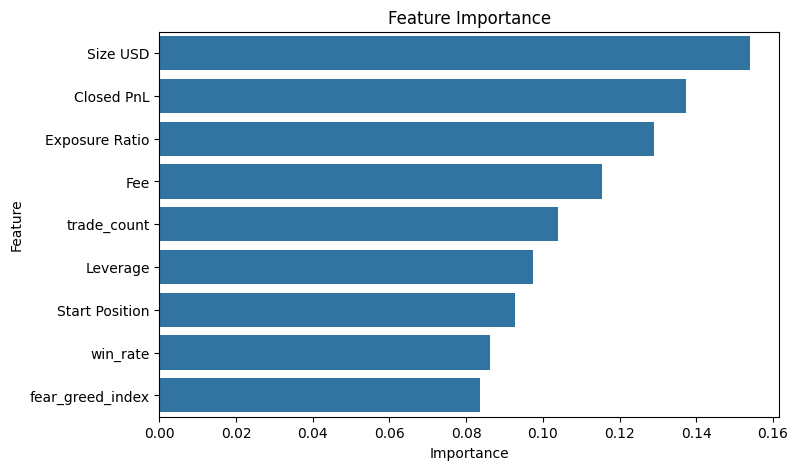

In [208]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Feature Importance"
)

plt.show()

CONCLUSION: size usd is most important feature followed by size usd,closed pnl,exposure ratio,fee,trade_count,leverage,start position,win_rate and fear_greed_index